# FoldFlow + CFG para generación plausible del estado conformacional opuesto

## Objetivo

Este experimento genera una **hipótesis estructural plausible** de una quinasa en el estado
conformacional contrario:

- activa → hipótesis inactiva;
- inactiva → hipótesis activa.

No se supone que exista un único PDB correcto para cada entrada. Las estructuras del estado opuesto
se usan como muestras débiles de una distribución destino. Por eso, el éxito no se define por RMSD
contra una pareja arbitraria, sino por la combinación de:

1. desplazamiento hacia rasgos locales del estado objetivo;
2. plausibilidad geométrica;
3. conservación razonable de la estructura global;
4. cercanía a la distribución de estructuras reales;
5. superioridad frente a baselines.

**Alcance.** El repositorio no contiene una implementación funcional del FoldFlow SE(3) oficial.
Se usa una variante FoldFlow-style sobre trazas C-alpha alineadas por secuencia, con Flow Matching,
Transformer y Classifier-Free Guidance. Las salidas son hipótesis geométricas, no estructuras
atómicas listas para simulación o diseño farmacológico.


In [8]:
from __future__ import annotations

import json, os, sys, math, random, warnings
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

def find_project_root(start=Path.cwd()):
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data/metadata/kinase_labels.csv").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz de TPF_Vision_Avanzada.")

ROOT = find_project_root()
TRAINING = ROOT / "training"
if str(TRAINING) not in sys.path:
    sys.path.insert(0, str(TRAINING))

import plausible_inverse_state_generation as exp

SMOKE = os.getenv("FOLDFLOW_PLAUSIBLE_SMOKE", "0") == "1"
OUTPUT = (
    Path("/private/tmp/foldflow_cfg_plausible_inverse_state_generation_smoke")
    if SMOKE else ROOT / "outputs/foldflow_cfg_plausible_inverse_state_generation"
)
CHECKPOINTS = OUTPUT / "checkpoints"
METRICS = OUTPUT / "metrics"
FIGURES = OUTPUT / "figures"
EXAMPLES = OUTPUT / "generated_examples"
for directory in (OUTPUT, CHECKPOINTS, METRICS, FIGURES, EXAMPLES):
    directory.mkdir(parents=True, exist_ok=True)

CONFIG = exp.Config()
if SMOKE:
    CONFIG.epochs = 2
    CONFIG.patience = 2
    CONFIG.batch_size = 4
    CONFIG.num_points = 96
    CONFIG.hidden_dim = 64
    CONFIG.num_layers = 2
    CONFIG.integration_steps = 3
    CONFIG.max_sources_per_kinase = 4
    CONFIG.max_eval_sources_per_kinase = 2
    CONFIG.validation_every = 1
    CONFIG.guidance_sweep = (0.0, 1.0)

exp.set_seed(CONFIG.seed)
DEVICE = exp.device_name()
sns.set_theme(style="whitegrid")
exp.save_config(CONFIG, OUTPUT, DEVICE)
print("Proyecto:", ROOT)
print("Dispositivo:", DEVICE)
print("Modo smoke:", SMOKE)
print("Outputs:", OUTPUT)


Proyecto: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada
Dispositivo: mps
Modo smoke: False
Outputs: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/outputs/foldflow_cfg_plausible_inverse_state_generation


## 1. Carga, limpieza y auditoría

Se eliminan PDB duplicados y etiquetas contradictorias antes de leer coordenadas. Los motivos se
detectan sobre la secuencia reconstruida desde cada PDB:

- DFG y HRD por coincidencia de secuencia;
- Lys por el motivo VAIK;
- Glu de alphaC como el Glu conservado anterior a VAIK;
- activation loop desde DFG hacia los siguientes 25 residuos.


In [9]:
records, structure_audit, dataset_summary = exp.load_structures(ROOT)
structure_audit.to_csv(METRICS / "structure_loading_audit.csv", index=False)
dataset_summary.to_csv(METRICS / "dataset_summary.csv", index=False)

valid_rows = [
    {
        "split": split, "pdb_id": record.pdb_id, "kinase": record.kinase,
        "state": record.state, "dfg_state": record.dfg_state,
        "alphac_state": record.alphac_state, "resolution": record.resolution,
        "residues": len(record.residues), "dfg_found": record.dfg_index is not None,
        "hrd_found": record.hrd_index is not None,
        "vaik_lys_found": record.vaik_lys_index is not None,
        "alphac_glu_found": record.alphac_glu_index is not None,
    }
    for split, values in records.items() for record in values
]
valid_index = pd.DataFrame(valid_rows)
valid_index.to_csv(METRICS / "valid_structure_index.csv", index=False)
state_by_kinase = pd.crosstab(valid_index.kinase, valid_index.state)
state_by_kinase.to_csv(METRICS / "state_by_kinase.csv")
length_statistics = valid_index.groupby(["split", "state"]).residues.describe().reset_index()
length_statistics.to_csv(METRICS / "sequence_length_statistics.csv", index=False)
valid_index["activation_loop_found"] = valid_index.dfg_found
valid_index["lys_glu_pair_found"] = valid_index.vaik_lys_found & valid_index.alphac_glu_found
motif_coverage = valid_index.groupby(["split", "state"])[
    ["dfg_found", "hrd_found", "vaik_lys_found", "alphac_glu_found",
     "activation_loop_found", "lys_glu_pair_found"]
].mean().reset_index()
motif_coverage.to_csv(METRICS / "motif_structural_coverage.csv", index=False)
overall_coverage = pd.DataFrame([{
    "total_records": len(structure_audit),
    "valid_structures": int(structure_audit.valid.sum()),
}])
overall_coverage["valid_fraction"] = overall_coverage.valid_structures / overall_coverage.total_records
overall_coverage.to_csv(METRICS / "overall_structural_coverage.csv", index=False)

display(dataset_summary)
display(state_by_kinase.assign(total=state_by_kinase.sum(1)).sort_values("total", ascending=False))
display(length_statistics)
display(motif_coverage)
display(overall_coverage)
display(structure_audit.groupby("valid").size().rename("count").reset_index())


,raw_records,raw_unique_pdb,conflicting_pdb_removed,valid_unique_structures,active,inactive,kinases
0,1777,863,15,848,446,402,13


state,active,inactive,total
kinase,,,
EGFR,159,102,261
BRAF,19,85,104
MET,6,95,101
PIK3CA,97,3,100
ALK,61,3,64
FGFR1,59,1,60
ABL1,7,35,42
KIT,10,25,35
AKT1,16,17,33


,split,state,count,mean,std,min,25%,50%,75%,max
0,test,active,99.0,954.232323,134.993260,286.0,896.50,994.0,1023.5,1205.0
1,test,inactive,12.0,493.666667,317.806783,279.0,315.50,337.0,501.5,1046.0
2,train,active,331.0,293.102719,16.551161,209.0,283.00,295.0,304.0,329.0
3,train,inactive,270.0,294.196296,62.504977,234.0,263.00,274.0,297.0,614.0
4,val,active,16.0,288.875000,10.935416,259.0,285.25,292.5,297.0,299.0
5,val,inactive,120.0,288.625000,29.139497,225.0,278.00,287.0,293.0,441.0


,split,state,dfg_found,hrd_found,vaik_lys_found,alphac_glu_found,activation_loop_found,lys_glu_pair_found
0,test,active,0.989899,0.030303,1.000000,1.000000,0.989899,1.000000
1,test,inactive,1.000000,0.750000,1.000000,1.000000,1.000000,1.000000
2,train,active,0.984894,0.951662,0.993958,0.993958,0.984894,0.993958
3,train,inactive,0.940741,0.900000,0.977778,0.962963,0.940741,0.962963
4,val,active,0.937500,1.000000,1.000000,1.000000,0.937500,1.000000
5,val,inactive,0.925000,0.975000,1.000000,1.000000,0.925000,1.000000


,total_records,valid_structures,valid_fraction
0,848,848,1.0


,valid,count
0,True,848


## 2. Banco de estructuras reales y clasificador congelado

El clasificador se entrena solamente con estructuras reales del split de entrenamiento. Sus
probabilidades se usan como una métrica de cambio de estado, nunca como criterio suficiente.

También se construyen perfiles robustos de geometría local por estado y, cuando hay datos,
por quinasa. Para quinasas no vistas se usa la mediana global del estado objetivo.


In [10]:
real_metadata, real_features, real_banks = exp.build_real_feature_bank(records, CONFIG)
real_metadata.to_csv(METRICS / "real_feature_index.csv", index=False)
np.savez_compressed(METRICS / "real_feature_bank.npz", features=real_features)

state_classifier, classifier_report = exp.train_frozen_classifier(real_metadata, real_features)
classifier_report.to_csv(METRICS / "frozen_classifier_report.csv", index=False)
profile_lookup, global_profiles = exp.distribution_profiles(real_metadata, real_features)

display(classifier_report)
if (classifier_report.query("split == 'test'").balanced_accuracy < 0.65).any():
    warnings.warn(
        "El clasificador congelado generaliza débilmente al test OOD. "
        "Sus probabilidades deben interpretarse junto con métricas geométricas."
    )


,split,samples,balanced_accuracy,roc_auc
0,train,601,0.843963,0.895949
1,val,136,0.535417,0.782292
2,test,111,0.323232,0.390572


/var/folders/cj/3myknj8n1jvcbnqjybggkqlr0000gn/T/ipykernel_20169/3476617420.py:11: UserWarning: El clasificador congelado generaliza débilmente al test OOD. Sus probabilidades deben interpretarse junto con métricas geométricas.
  warnings.warn(


## 3. Pares débiles y representación

Cada estructura fuente se alinea por secuencia con una muestra real de la misma quinasa y del estado
opuesto. Durante entrenamiento el destino cambia de forma determinista entre épocas. Esto evita
convertir una pareja arbitraria en ground truth único.

El remuestreo conserva explícitamente posiciones de DFG, alphaC, HRD, activation loop, Lys y Glu.


In [11]:
train_kinases = sorted({record.kinase for record in records["train"]})
KINASE_VOCAB = {"<UNK>": 0, **{name: i + 1 for i, name in enumerate(train_kinases)}}

datasets = {
    split: exp.WeakDistributionDataset(
        values, CONFIG, KINASE_VOCAB, profile_lookup, global_profiles,
        training=(split == "train"),
    )
    for split, values in records.items()
}
if SMOKE:
    for split in ("val", "test"):
        datasets[split].sources = datasets[split].sources[:8]

loaders = {
    split: DataLoader(
        dataset, batch_size=CONFIG.batch_size, shuffle=(split == "train"),
        num_workers=CONFIG.num_workers,
        generator=torch.Generator().manual_seed(CONFIG.seed),
    )
    for split, dataset in datasets.items()
}

dataset_rows = []
for split, dataset in datasets.items():
    for source in dataset.sources:
        target_state = exp.STATES[1 - exp.STATES.index(source.state)]
        dataset_rows.append({
            "split": split, "source_pdb": source.pdb_id, "kinase": source.kinase,
            "source_state": source.state, "target_state": target_state,
            "direction": f"{source.state}_to_{target_state}",
        })
weak_dataset_index = pd.DataFrame(dataset_rows)
weak_dataset_index.to_csv(METRICS / "weak_distribution_samples.csv", index=False)
display(weak_dataset_index.groupby(["split", "direction"]).size().rename("samples").reset_index())

sample_raw = next(iter(loaders["train"]))
print("x0:", tuple(sample_raw["x0"].shape))
print("x1 débil:", tuple(sample_raw["x1"].shape))
print("perfil objetivo:", tuple(sample_raw["target_profile"].shape))
print("DFG preservado en representación:", sample_raw["dfg_mask"].sum(1).tolist())


,split,direction,samples
0,test,active_to_inactive,99
1,test,inactive_to_active,12
2,train,active_to_inactive,262
3,train,inactive_to_active,206
4,val,active_to_inactive,16
5,val,inactive_to_active,120


x0: (8, 192, 3)
x1 débil: (8, 192, 3)
perfil objetivo: (8, 15)
DFG preservado en representación: [7, 6, 0, 6, 7, 7, 7, 7]


## 4. FoldFlow-style + Classifier-Free Guidance

El campo de velocidad se condiciona por estado fuente, estado objetivo, quinasa, perfil local
objetivo y roles funcionales por residuo. El dropout de condición permite combinar:

`v_cfg = v_uncond + guidance_scale * (v_cond - v_uncond)`.

Además del loss de Flow Matching se penalizan:

- geometría C-alpha inconsistente;
- destrucción del core fuera de regiones funcionales;
- alejamiento del perfil geométrico del estado objetivo.


In [12]:
feature_dim = real_features.shape[1]
model = exp.FoldFlowCFG(CONFIG, len(KINASE_VOCAB), feature_dim).to(DEVICE)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=CONFIG.learning_rate, weight_decay=CONFIG.weight_decay
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG.epochs)
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters()):,}")

sample = exp.move_batch(sample_raw, DEVICE)
with torch.no_grad():
    output = model(sample["x0"], torch.rand(len(sample["x0"]), device=DEVICE), sample)
assert output.shape == sample["x0"].shape
print("Forward válido:", tuple(output.shape))


Parámetros entrenables: 1,304,099
Forward válido: (8, 192, 3)


/Users/josefinadehan/miniforge3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 5. Entrenamiento con early stopping

El checkpoint no se elige exclusivamente por denoising loss. El score de validación agrega:

- loss total;
- error geométrico;
- distancia al perfil del estado objetivo;
- fracción de enlaces C-alpha inválidos.

El límite es 500 épocas, con early stopping por defecto después de 30 evaluaciones sin mejora.


In [13]:
def evaluate_validation(model, loader, generate):
    model.eval()
    losses, components, generated_rows = [], [], []
    with torch.no_grad():
        for raw in loader:
            batch = exp.move_batch(raw, DEVICE)
            loss, parts = exp.flow_objective(model, batch, CONFIG, training=False)
            losses.append(float(loss))
            components.append(parts)
            if generate:
                generated = exp.integrate(
                    model, batch, CONFIG.guidance_scale,
                    CONFIG.integration_steps, save_times=(1.0,),
                )[1.0].to(DEVICE)
                rows = exp.evaluate_coordinates(
                    generated, batch, state_classifier, real_banks["val"]
                )
                generated_rows.append(rows)
    parts = pd.DataFrame(components).mean().to_dict()
    result = {"validation_total_loss": np.mean(losses), **{f"validation_{k}": v for k, v in parts.items()}}
    if generated_rows:
        frame = pd.concat(generated_rows, ignore_index=True)
        result.update({
            "validation_target_probability": frame.target_probability.mean(),
            "validation_accuracy": frame.classifier_correct.mean(),
            "validation_geometric_validity": frame.ca_bond_valid_fraction.mean(),
            "validation_broken_geometry": frame.broken_geometry_fraction.mean(),
            "validation_source_generated_rmsd": frame.global_source_generated_rmsd.mean(),
            "validation_target_neighbor_distance": frame.target_neighbor_feature_distance.mean(),
        })
    return result

def generated_accuracy(model, loader, bank, max_batches=4):
    rows = []
    model.eval()
    with torch.no_grad():
        for batch_index, raw in enumerate(loader):
            if batch_index >= max_batches:
                break
            batch = exp.move_batch(raw, DEVICE)
            generated = exp.integrate(
                model, batch, CONFIG.guidance_scale, CONFIG.integration_steps
            )[1.0].to(DEVICE)
            rows.append(exp.evaluate_coordinates(generated, batch, state_classifier, bank))
    frame = pd.concat(rows, ignore_index=True)
    return frame.classifier_correct.mean(), frame.target_probability.mean()

history, best_score, stale = [], float("inf"), 0
best_epoch = 0
epoch_bar = tqdm(range(1, CONFIG.epochs + 1), desc="Entrenamiento")
for epoch in epoch_bar:
    datasets["train"].set_epoch(epoch)
    model.train()
    train_rows = []
    for raw in loaders["train"]:
        batch = exp.move_batch(raw, DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss, parts = exp.flow_objective(model, batch, CONFIG, training=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG.grad_clip)
        optimizer.step()
        train_rows.append({"train_total_loss": float(loss.detach()), **{f"train_{k}": v for k, v in parts.items()}})
    compute_generation = epoch == 1 or epoch % CONFIG.validation_every == 0
    validation = evaluate_validation(model, loaders["val"], compute_generation)
    train_accuracy = train_probability = np.nan
    if compute_generation:
        train_accuracy, train_probability = generated_accuracy(
            model, loaders["train"], real_banks["train"]
        )
    row = {
        "epoch": epoch,
        **pd.DataFrame(train_rows).mean().to_dict(),
        **validation,
        "train_accuracy": train_accuracy,
        "train_target_probability": train_probability,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    geometry_penalty = validation.get("validation_broken_geometry", 0.0)
    profile_penalty = validation.get("validation_target_neighbor_distance", 0.0)
    score = validation["validation_total_loss"] + 0.25 * geometry_penalty + 0.02 * profile_penalty
    checkpoint = {
        "model_state": model.state_dict(), "optimizer_state": optimizer.state_dict(),
        "epoch": epoch, "selection_score": score, "config": asdict(CONFIG),
        "kinase_vocab": KINASE_VOCAB, "feature_dim": feature_dim,
    }
    torch.save(checkpoint, CHECKPOINTS / "last_model.pt")
    if score < best_score:
        best_score, best_epoch, stale = score, epoch, 0
        torch.save(checkpoint, CHECKPOINTS / "best_model.pt")
    else:
        stale += int(compute_generation)
    scheduler.step()
    epoch_bar.set_postfix(train=f"{row['train_total_loss']:.4f}", val=f"{validation['validation_total_loss']:.4f}", best=best_epoch)
    pd.DataFrame(history).to_csv(METRICS / "training_history.csv", index=False)
    if epoch >= max(10, CONFIG.validation_every) and stale >= CONFIG.patience:
        print(f"Early stopping en epoch {epoch}; mejor epoch={best_epoch}.")
        break

history_df = pd.DataFrame(history)
history_df[[
    "epoch", "train_total_loss", "validation_total_loss",
    "train_accuracy", "validation_accuracy",
]].to_csv(METRICS / "train_validation_loss_accuracy_history.csv", index=False)
best = torch.load(CHECKPOINTS / "best_model.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(best["model_state"])
model.eval()
print("Mejor epoch:", best["epoch"], "| score compuesto:", best["selection_score"])


Entrenamiento:  69%|██████▉   | 344/500 [11:41:09<5:17:58, 122.30s/it, best=196, train=0.0042, val=0.0237] 

Early stopping en epoch 345; mejor epoch=196.
Mejor epoch: 196 | score compuesto: 0.022567396600018528


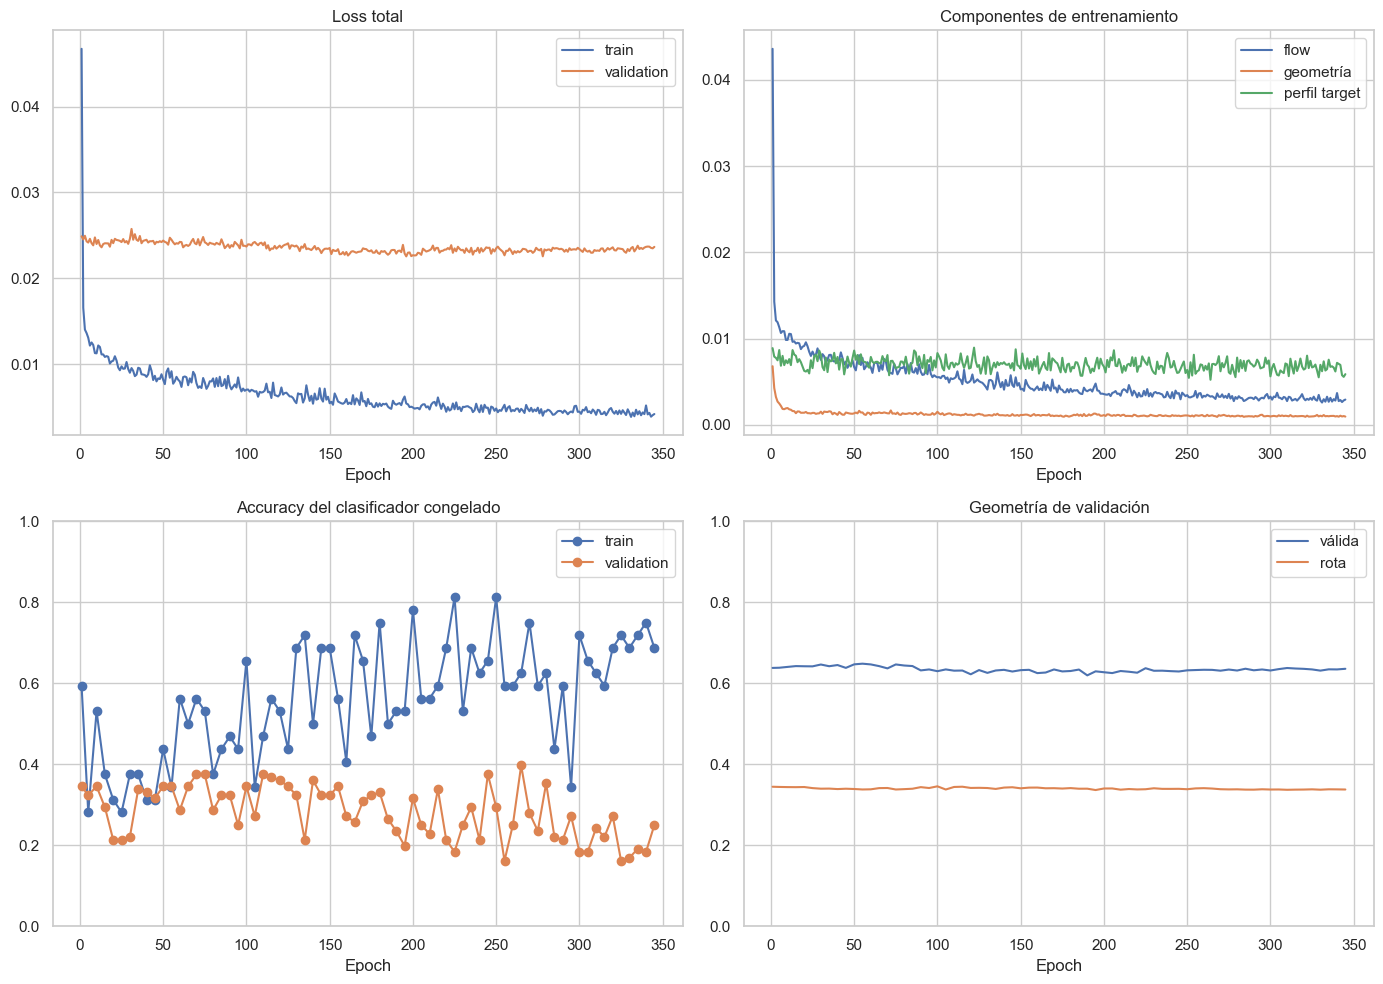

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(history_df.epoch, history_df.train_total_loss, label="train")
axes[0, 0].plot(history_df.epoch, history_df.validation_total_loss, label="validation")
axes[0, 0].set(title="Loss total", xlabel="Epoch"); axes[0, 0].legend()
axes[0, 1].plot(history_df.epoch, history_df.train_flow_loss, label="flow")
axes[0, 1].plot(history_df.epoch, history_df.train_geometry_loss, label="geometría")
axes[0, 1].plot(history_df.epoch, history_df.train_target_profile_loss, label="perfil target")
axes[0, 1].set(title="Componentes de entrenamiento", xlabel="Epoch"); axes[0, 1].legend()
observed = history_df.dropna(subset=["validation_accuracy"])
axes[1, 0].plot(observed.epoch, observed.train_accuracy, marker="o", label="train")
axes[1, 0].plot(observed.epoch, observed.validation_accuracy, marker="o", label="validation")
axes[1, 0].set(title="Accuracy del clasificador congelado", xlabel="Epoch", ylim=(0, 1))
axes[1, 0].legend()
axes[1, 1].plot(observed.epoch, observed.validation_geometric_validity, label="válida")
axes[1, 1].plot(observed.epoch, observed.validation_broken_geometry, label="rota")
axes[1, 1].set(title="Geometría de validación", xlabel="Epoch", ylim=(0, 1)); axes[1, 1].legend()
fig.tight_layout()
fig.savefig(FIGURES / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Barrido de CFG y baselines

Se selecciona `guidance_scale` sobre validación, no sobre test. Los baselines obligatorios son:

- copiar la entrada;
- ruido aleatorio;
- estructura real alineada del estado objetivo (vecino real/oráculo);
- promedio del minibatch del estado objetivo;
- interpolación simple hacia un ejemplo real.

El vecino real y la interpolación usan información destino y funcionan como referencias superiores,
no como métodos desplegables sin una base de estructuras reales.


In [15]:
def evaluate_method_frame(method, coordinates, batch, bank):
    frame = exp.evaluate_coordinates(coordinates, batch, state_classifier, bank)
    frame["method"] = method
    return frame

guidance_rows = []
for scale in tqdm(CONFIG.guidance_sweep, desc="Barrido CFG"):
    frames = []
    for raw in loaders["val"]:
        batch = exp.move_batch(raw, DEVICE)
        generated = exp.integrate(model, batch, scale, CONFIG.integration_steps)[1.0].to(DEVICE)
        frames.append(evaluate_method_frame("foldflow_cfg", generated, batch, real_banks["val"]))
    frame = pd.concat(frames, ignore_index=True)
    guidance_rows.append({
        "guidance_scale": scale,
        "target_probability": frame.target_probability.mean(),
        "geometric_validity": frame.ca_bond_valid_fraction.mean(),
        "broken_geometry": frame.broken_geometry_fraction.mean(),
        "target_neighbor_distance": frame.target_neighbor_feature_distance.mean(),
        "global_rmsd": frame.global_source_generated_rmsd.mean(),
    })
guidance_sweep = pd.DataFrame(guidance_rows)
guidance_sweep["selection_score"] = (
    guidance_sweep.target_neighbor_distance
    + 5 * guidance_sweep.broken_geometry
    - 2 * guidance_sweep.target_probability
)
SELECTED_GUIDANCE = float(guidance_sweep.sort_values("selection_score").iloc[0].guidance_scale)
guidance_sweep.to_csv(METRICS / "guidance_sweep.csv", index=False)
display(guidance_sweep)
print("Guidance seleccionado en validación:", SELECTED_GUIDANCE)


Barrido CFG: 100%|██████████| 6/6 [47:04<00:00, 470.77s/it]  


,guidance_scale,target_probability,geometric_validity,broken_geometry,target_neighbor_distance,global_rmsd,selection_score
0,0.0,0.262414,0.638476,0.343457,0.243934,0.885503,1.436392
1,0.5,0.255780,0.644068,0.340761,0.235080,0.731089,1.427324
2,1.0,0.298979,0.639531,0.339814,0.233928,0.993967,1.335040
3,1.5,0.338967,0.628458,0.342951,0.253065,1.479810,1.289888
4,2.0,0.373218,0.610137,0.345708,0.278067,1.983788,1.260171
5,3.0,0.439768,0.567339,0.351037,0.338584,2.950713,1.214232


Guidance seleccionado en validación: 3.0


## 7. Testing final multicomponente

Las métricas se calculan por muestra y luego se agregan por dirección, quinasa, motivos fuente y
dificultad. La dificultad se define por terciles de distancia inicial a la distribución objetivo.


In [16]:
test_frames = []
example_payload = None
for raw in tqdm(loaders["test"], desc="Test final"):
    batch = exp.move_batch(raw, DEVICE)
    trajectory = exp.integrate(
        model, batch, SELECTED_GUIDANCE, CONFIG.integration_steps,
        save_times=(0.0, 0.25, 0.5, 0.75, 1.0),
    )
    generated = trajectory[1.0].to(DEVICE)
    test_frames.append(evaluate_method_frame("foldflow_cfg", generated, batch, real_banks["test"]))
    for name, coordinates in exp.make_baselines(batch).items():
        test_frames.append(evaluate_method_frame(name, coordinates, batch, real_banks["test"]))
    if example_payload is None:
        example_payload = (raw, batch, trajectory)

test_details = pd.concat(test_frames, ignore_index=True)
copy_distance = (
    test_details.query("method == 'copy_source'")
    .set_index(["source_pdb", "direction"]).target_neighbor_feature_distance
)
test_details["copy_target_neighbor_distance"] = [
    copy_distance.loc[(row.source_pdb, row.direction)] for row in test_details.itertuples()
]
test_details["improvement_vs_copy"] = (
    test_details.copy_target_neighbor_distance - test_details.target_neighbor_feature_distance
)
source_difficulty = copy_distance.rename("initial_target_distance").reset_index()
source_difficulty["difficulty"] = pd.qcut(
    source_difficulty.initial_target_distance.rank(method="first"),
    3, labels=["easy", "medium", "hard"],
)
test_details = test_details.merge(source_difficulty, on=["source_pdb", "direction"], how="left")
test_details.to_csv(METRICS / "test_per_sample_and_baselines.csv", index=False)

test_summary = exp.summarize_test(test_details)
improvement = (
    test_details.groupby(["method", "direction"]).improvement_vs_copy.mean()
    .rename("improvement_vs_copy").reset_index()
)
test_summary = test_summary.merge(improvement, on=["method", "direction"], how="left")
noise_residue_error = (
    test_summary.query("method == 'random_noise'")
    .set_index("direction").weak_target_residue_mae
)
test_summary["residue_error_improvement_vs_noise"] = [
    noise_residue_error.get(row.direction, np.nan) - row.weak_target_residue_mae
    for row in test_summary.itertuples()
]
test_summary.to_csv(METRICS / "test_summary.csv", index=False)
display(test_summary)


Test final: 100%|██████████| 14/14 [15:46<00:00, 67.60s/it] 


,method,direction,n_samples,target_state_probability,frozen_classifier_accuracy,dfg_change,alphac_change,hrd_dfg_change,lys_glu_change,activation_loop_change,rmsd_source_generated,mean_residue_error,residue_rmse,weak_target_residue_mae,weak_target_residue_rmse,geometric_validity,broken_geometry,nearest_real_target_distance,improvement_vs_copy,residue_error_improvement_vs_noise
0,copy_source,active_to_inactive,99,9.494175e-01,0.979798,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.551604,2.305859,0.187954,0.808134,0.193544,0.000000,1.673332
1,copy_source,inactive_to_active,12,5.130044e-01,0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.414219,4.284942,0.489092,0.507853,0.077554,0.000000,0.903103
2,foldflow_cfg,active_to_inactive,99,9.051188e-01,0.979798,-0.040053,0.022175,0.191095,0.007323,5.513014,4.515582,3.493693,4.515582,4.147758,5.416351,0.145961,0.818842,0.225045,-0.031502,-0.922822
3,foldflow_cfg,inactive_to_active,12,3.803565e-01,0.333333,-0.010482,0.054101,0.675449,-0.348351,8.913252,4.424951,3.032424,4.424951,3.550242,5.119592,0.385689,0.537522,0.171717,-0.094164,-0.232920
4,nearest_target_state,active_to_inactive,99,8.726092e-01,0.959596,0.000836,0.004341,-0.009232,0.036206,2.579258,2.305859,1.551604,2.305859,0.000000,0.000000,0.186075,0.810223,0.193127,0.000417,3.224936
5,nearest_target_state,inactive_to_active,12,7.236113e-01,0.750000,0.021035,-0.005046,0.419539,-0.239564,9.189200,4.284942,2.414219,4.284942,0.000000,0.000000,0.489092,0.509599,0.054518,0.023036,3.317322
6,random_noise,active_to_inactive,99,9.226459e-01,0.979798,0.030022,0.017570,-0.000165,0.359942,2.695020,2.697246,2.490712,2.697246,3.224936,3.781049,0.042824,0.895601,0.236160,-0.042616,0.000000
7,random_noise,inactive_to_active,12,6.041896e-01,0.666667,-0.017067,0.007513,0.570303,1.841975,1.947146,1.925110,1.777752,1.925110,3.317322,4.947142,0.157941,0.634817,0.161408,-0.083854,0.000000
8,simple_interpolation,active_to_inactive,99,9.485765e-01,0.989899,-0.003730,0.000717,-0.002608,-0.014238,0.644814,0.576465,0.387901,0.576465,1.163703,1.729395,0.173595,0.811015,0.191824,0.001720,2.061233
9,simple_interpolation,inactive_to_active,12,5.324797e-01,0.583333,-0.001022,-0.000599,0.093956,-0.077053,2.297300,1.071236,0.603555,1.071236,1.810664,3.213707,0.450262,0.513962,0.102459,-0.024905,1.506658


In [17]:
model_test = test_details.query("method == 'foldflow_cfg'").copy()
by_kinase = model_test.groupby(["direction", "kinase"]).agg(
    samples=("source_pdb", "size"),
    target_probability=("target_probability", "mean"),
    classifier_accuracy=("classifier_correct", "mean"),
    global_rmsd=("global_source_generated_rmsd", "mean"),
    geometric_validity=("ca_bond_valid_fraction", "mean"),
    target_neighbor_distance=("target_neighbor_feature_distance", "mean"),
    improvement_vs_copy=("improvement_vs_copy", "mean"),
).reset_index()
by_motif = model_test.groupby(
    ["direction", "source_dfg_state", "source_alphac_state"], dropna=False
).agg(
    samples=("source_pdb", "size"),
    target_probability=("target_probability", "mean"),
    dfg_change=("dfg_target_progress", "mean"),
    alphac_change=("alphac_target_progress", "mean"),
    geometric_validity=("ca_bond_valid_fraction", "mean"),
).reset_index()
by_difficulty = model_test.groupby(["direction", "difficulty"], observed=True).agg(
    samples=("source_pdb", "size"),
    target_probability=("target_probability", "mean"),
    geometric_validity=("ca_bond_valid_fraction", "mean"),
    target_neighbor_distance=("target_neighbor_feature_distance", "mean"),
    improvement_vs_copy=("improvement_vs_copy", "mean"),
).reset_index()

by_kinase.to_csv(METRICS / "test_by_kinase.csv", index=False)
by_motif.to_csv(METRICS / "test_by_source_motif.csv", index=False)
by_difficulty.to_csv(METRICS / "test_by_difficulty.csv", index=False)
display(by_kinase)
display(by_motif)
display(by_difficulty)


,direction,kinase,samples,target_probability,classifier_accuracy,global_rmsd,geometric_validity,target_neighbor_distance,improvement_vs_copy
0,active_to_inactive,PDGFRA,2,1.924042e-07,0.000000,3.794599,0.361257,0.525337,-0.424581
1,active_to_inactive,PIK3CA,97,9.237811e-01,1.000000,4.530448,0.141522,0.218854,-0.023397
2,inactive_to_active,PDGFRA,9,5.068701e-01,0.444444,4.427031,0.466550,0.207836,-0.107593
3,inactive_to_active,PIK3CA,3,8.156341e-04,0.000000,4.418710,0.143106,0.063363,-0.053875


,direction,source_dfg_state,source_alphac_state,samples,target_probability,dfg_change,alphac_change,geometric_validity
0,active_to_inactive,in,in,98,0.904151,-0.040462,0.022402,0.143979
1,active_to_inactive,in,na,1,0.999959,0.000000,0.000000,0.340206
2,inactive_to_active,in,out,1,0.881865,-0.052736,0.051766,0.455497
3,inactive_to_active,out,in,7,0.472006,-0.019559,0.073536,0.480180
4,inactive_to_active,out-like,in,4,0.094593,0.015968,0.020673,0.202880


,direction,difficulty,samples,target_probability,geometric_validity,target_neighbor_distance,improvement_vs_copy
0,active_to_inactive,easy,34,0.954123,0.157222,0.058469,-0.042585
1,active_to_inactive,medium,34,0.884670,0.161072,0.071346,-0.036102
2,active_to_inactive,hard,31,0.873800,0.117038,0.576316,-0.014300
3,inactive_to_active,easy,3,0.000816,0.143106,0.063363,-0.053875
4,inactive_to_active,medium,3,0.491506,0.458988,0.201313,-0.120541
5,inactive_to_active,hard,6,0.514552,0.470332,0.211097,-0.101119


## 8. Visualizaciones estructurales

Las figuras muestran la traza C-alpha inicial, perturbada, trayectoria ODE, estructura generada y un
ejemplo real del estado objetivo. También incluyen superposiciones, error por residuo, matrices de
distancia y evolución de rasgos locales.


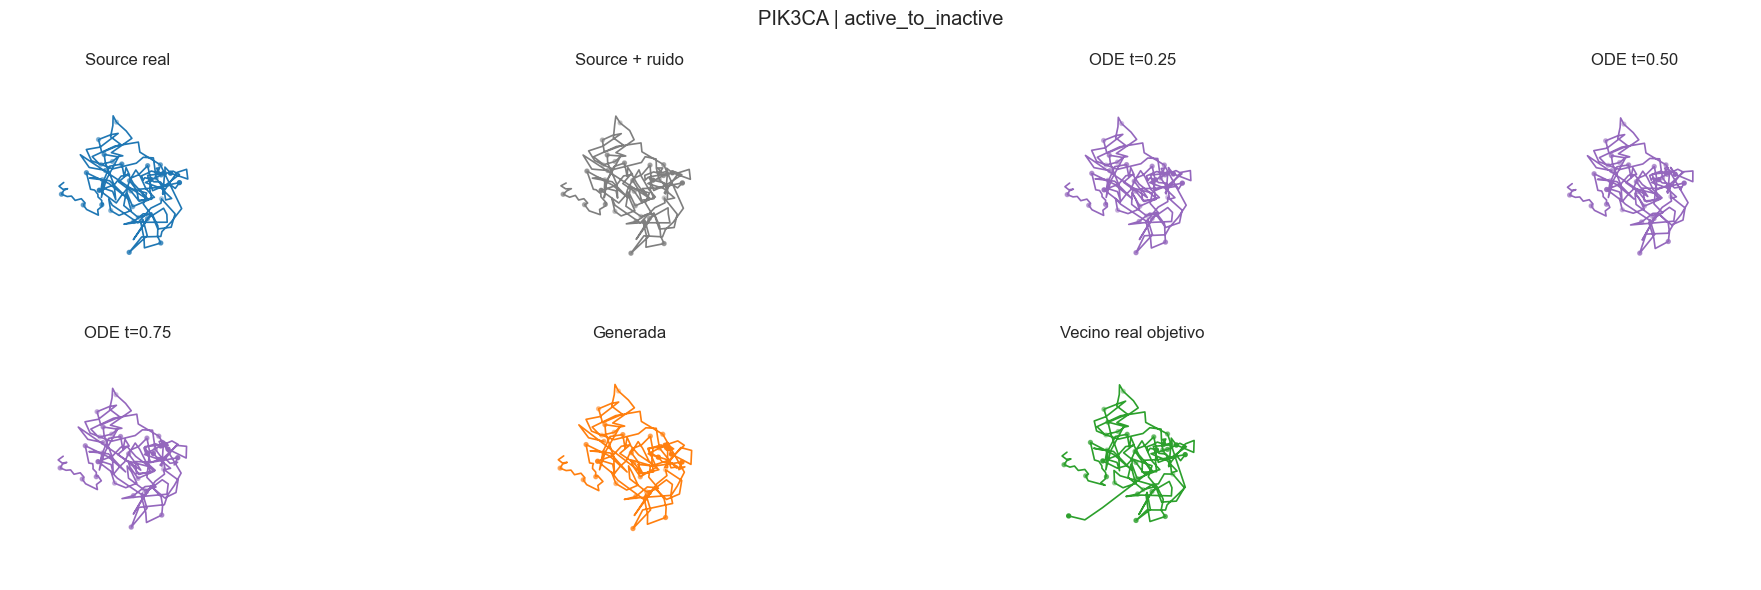

In [18]:
def set_equal_3d(ax, xyz):
    center = xyz.mean(0)
    radius = max(np.ptp(xyz, axis=0).max() / 2, 1e-6)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

def plot_trace(ax, xyz, title, color):
    ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=color, lw=1.2)
    ax.scatter(xyz[::6, 0], xyz[::6, 1], xyz[::6, 2], color=color, s=8)
    ax.set_title(title); ax.set_axis_off(); set_equal_3d(ax, xyz)

raw, batch, trajectory = example_payload
scale = float(raw["scale"][0])
mask = raw["mask"][0].bool().numpy()
source = raw["x0"][0].numpy()[mask] * scale
target_neighbor = raw["x1"][0].numpy()[mask] * scale
generated = trajectory[1.0][0].numpy()[mask] * scale
noisy = source + np.random.default_rng(CONFIG.seed).normal(0, CONFIG.noise_std * scale, source.shape)

panels = [
    (source, "Source real", "tab:blue"),
    (noisy, "Source + ruido", "tab:gray"),
    (trajectory[0.25][0].numpy()[mask] * scale, "ODE t=0.25", "tab:purple"),
    (trajectory[0.50][0].numpy()[mask] * scale, "ODE t=0.50", "tab:purple"),
    (trajectory[0.75][0].numpy()[mask] * scale, "ODE t=0.75", "tab:purple"),
    (generated, "Generada", "tab:orange"),
    (target_neighbor, "Vecino real objetivo", "tab:green"),
]
fig = plt.figure(figsize=(21, 6))
for index, (xyz, title, color) in enumerate(panels, 1):
    plot_trace(fig.add_subplot(2, 4, index, projection="3d"), xyz, title, color)
fig.suptitle(f"{raw['kinase_name'][0]} | {raw['direction'][0]}")
fig.tight_layout()
fig.savefig(FIGURES / "generation_trajectory_3d.png", dpi=200, bbox_inches="tight")
plt.show()


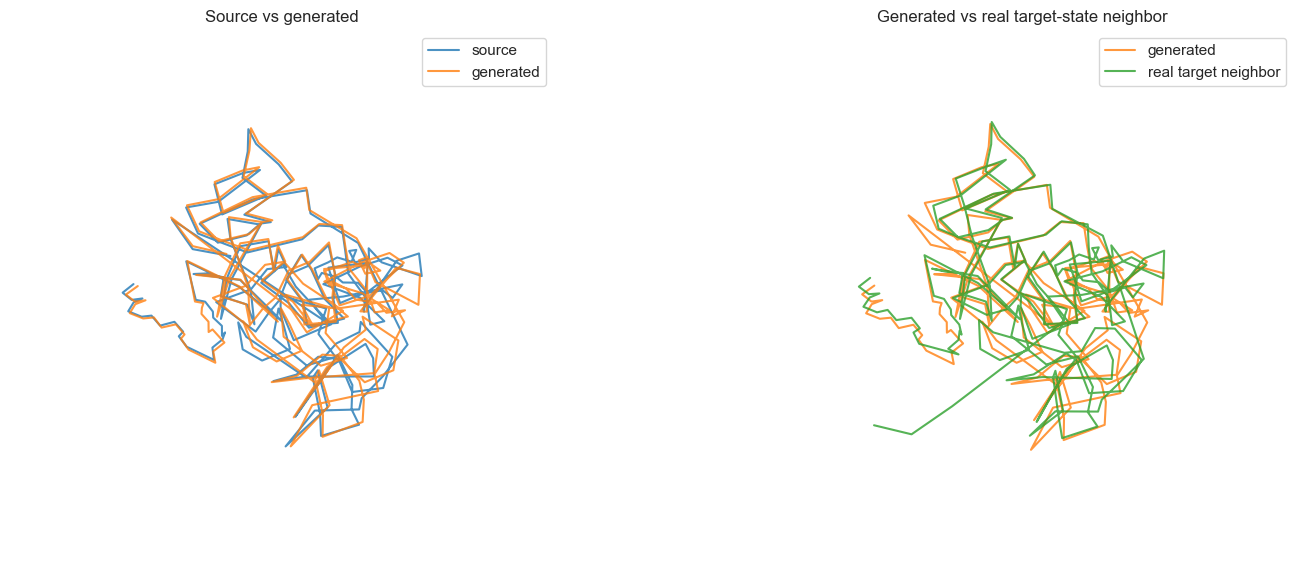

MAE por residuo vs vecino real: 4.468719
RMSE por residuo vs vecino real: 9.036466


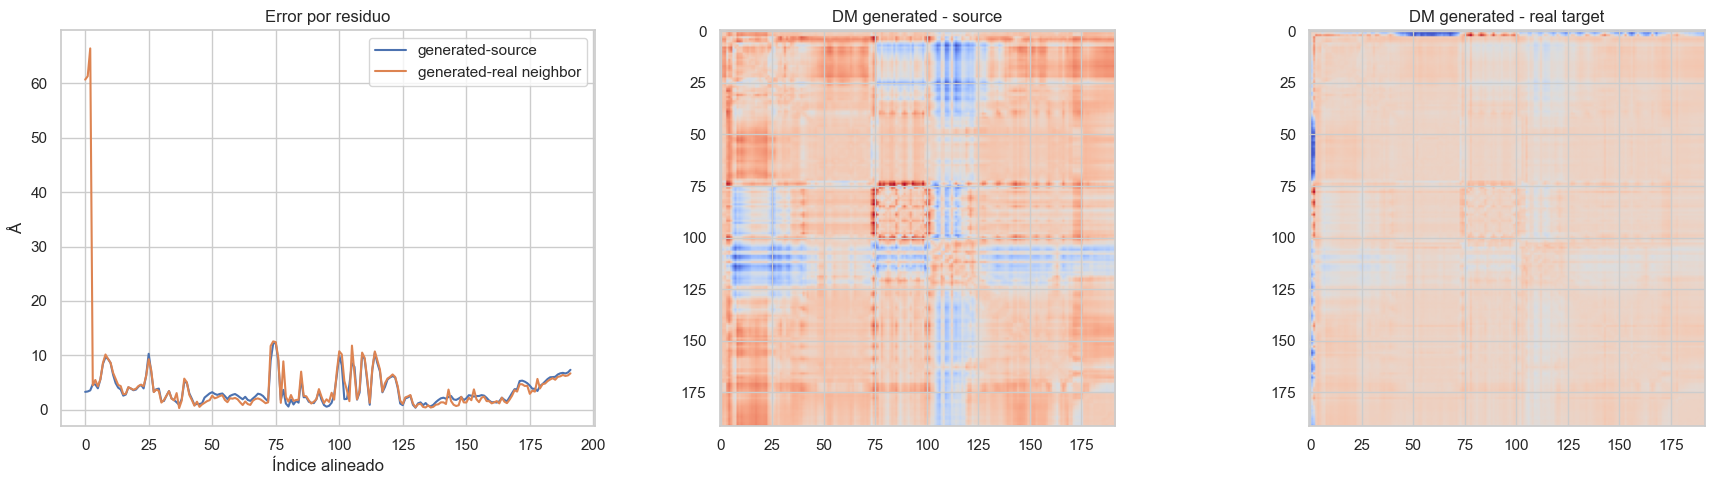

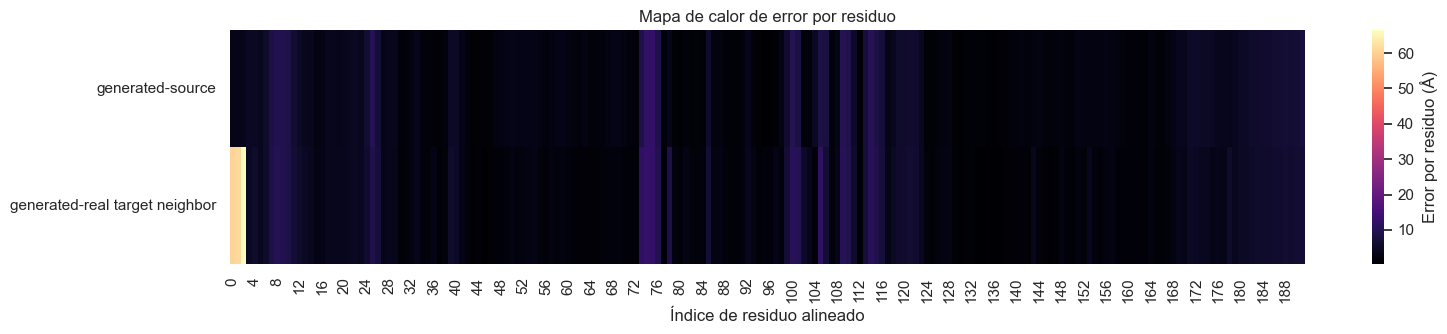

In [19]:
fig = plt.figure(figsize=(16, 6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
for xyz, label, color in [
    (source, "source", "tab:blue"), (generated, "generated", "tab:orange")
]:
    ax.plot(*xyz.T, label=label, color=color, alpha=0.8)
ax.legend(); ax.set_title("Source vs generated"); ax.set_axis_off()
set_equal_3d(ax, np.vstack([source, generated]))

ax = fig.add_subplot(1, 2, 2, projection="3d")
for xyz, label, color in [
    (generated, "generated", "tab:orange"), (target_neighbor, "real target neighbor", "tab:green")
]:
    ax.plot(*xyz.T, label=label, color=color, alpha=0.8)
ax.legend(); ax.set_title("Generated vs real target-state neighbor"); ax.set_axis_off()
set_equal_3d(ax, np.vstack([generated, target_neighbor]))
fig.tight_layout()
fig.savefig(FIGURES / "structural_overlays.png", dpi=200, bbox_inches="tight")
plt.show()

error_source = np.linalg.norm(generated - source, axis=-1)
error_target = np.linalg.norm(generated - target_neighbor, axis=-1)
residue_errors = pd.DataFrame({
    "residue_index": np.arange(len(error_source)),
    "generated_vs_source": error_source,
    "generated_vs_real_target_neighbor": error_target,
})
residue_errors.to_csv(METRICS / "example_residue_wise_error.csv", index=False)
print("MAE por residuo vs vecino real:", error_target.mean())
print("RMSE por residuo vs vecino real:", np.sqrt(np.mean(error_target ** 2)))
distance_matrices = [
    np.linalg.norm(x[:, None] - x[None], axis=-1)
    for x in (source, generated, target_neighbor)
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(error_source, label="generated-source")
axes[0].plot(error_target, label="generated-real neighbor")
axes[0].set(title="Error por residuo", xlabel="Índice alineado", ylabel="Å"); axes[0].legend()
axes[1].imshow(distance_matrices[1] - distance_matrices[0], cmap="coolwarm")
axes[1].set_title("DM generated - source")
axes[2].imshow(distance_matrices[1] - distance_matrices[2], cmap="coolwarm")
axes[2].set_title("DM generated - real target")
fig.tight_layout()
fig.savefig(FIGURES / "per_residue_and_distance_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(16, 3.5))
sns.heatmap(
    np.vstack([error_source, error_target]), cmap="magma", ax=ax,
    yticklabels=["generated-source", "generated-real target neighbor"],
    cbar_kws={"label": "Error por residuo (Å)"},
)
ax.set(xlabel="Índice de residuo alineado", title="Mapa de calor de error por residuo")
fig.tight_layout()
fig.savefig(FIGURES / "residue_wise_error_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


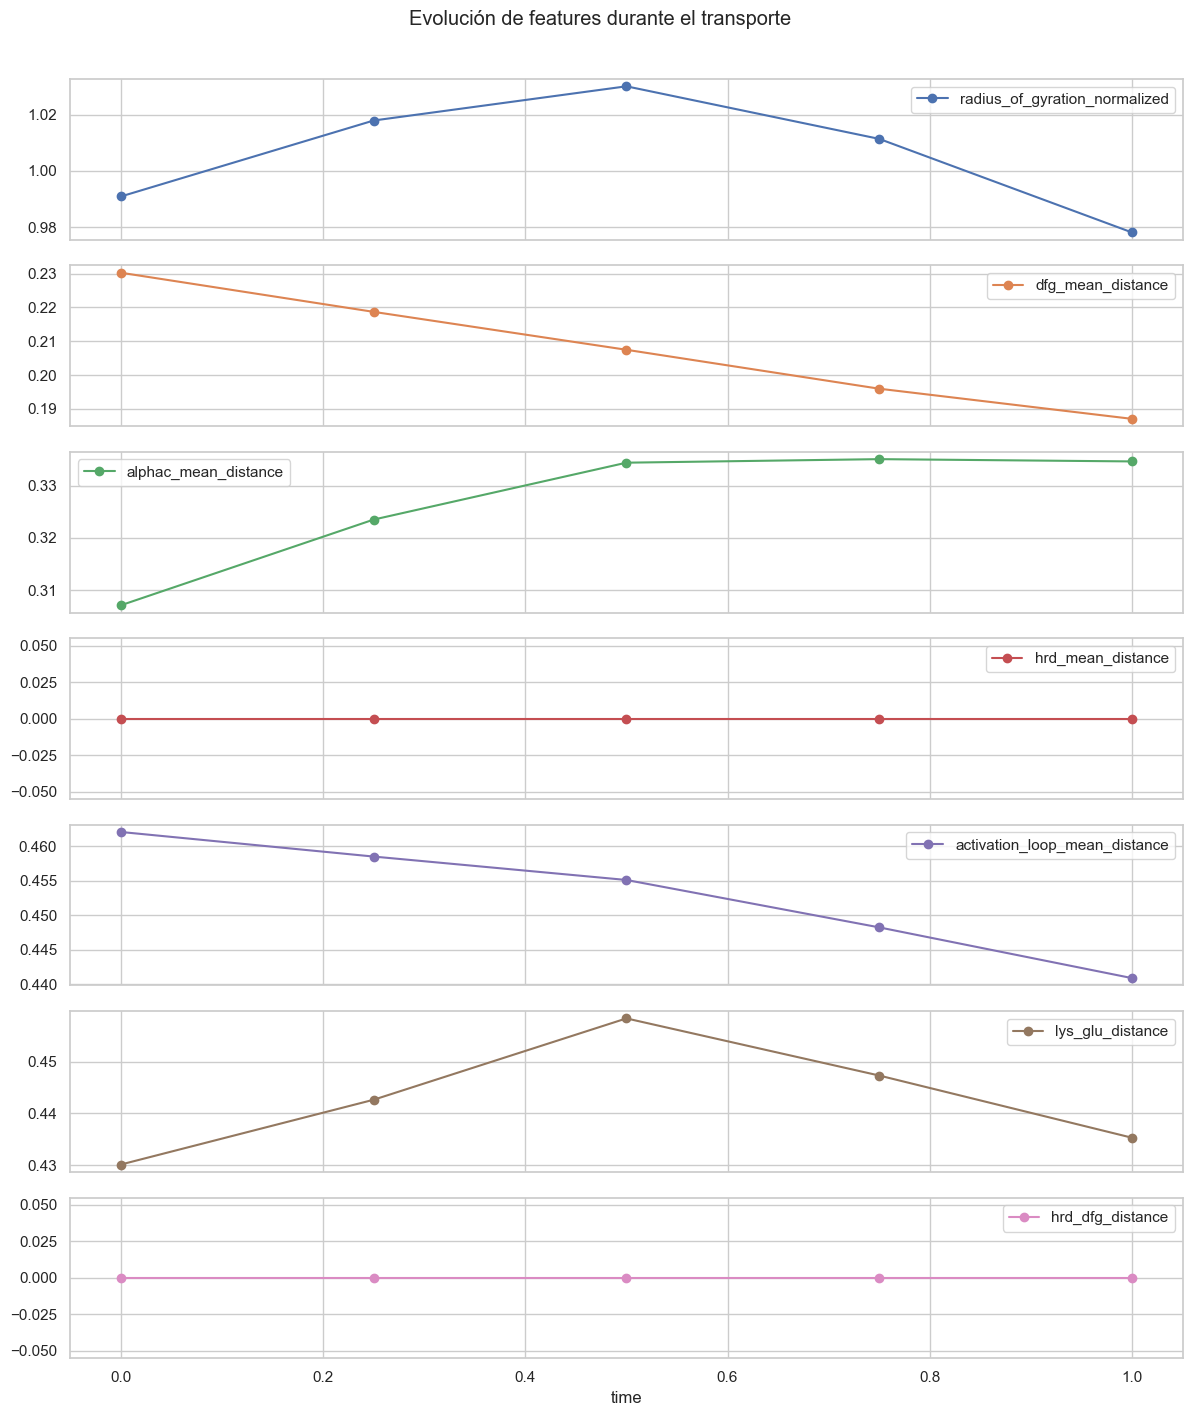

In [20]:
feature_path = []
for time in sorted(trajectory):
    coords = trajectory[time].to(DEVICE)
    features = exp.geometry_features(coords, batch).detach().cpu().numpy()[0]
    feature_path.append({
        "time": time,
        "radius_of_gyration_normalized": features[0],
        "dfg_mean_distance": features[5],
        "alphac_mean_distance": features[7],
        "hrd_mean_distance": features[9],
        "activation_loop_mean_distance": features[11],
        "lys_glu_distance": features[13],
        "hrd_dfg_distance": features[14],
    })
feature_path = pd.DataFrame(feature_path)
feature_path.to_csv(METRICS / "example_feature_trajectory.csv", index=False)
feature_path.set_index("time").plot(subplots=True, figsize=(12, 14), marker="o")
plt.suptitle("Evolución de features durante el transporte", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "feature_evolution_during_denoising.png", dpi=200, bbox_inches="tight")
plt.show()

np.savez_compressed(
    EXAMPLES / "test_example_coordinates.npz",
    source=source, noisy=noisy, generated=generated, real_target_neighbor=target_neighbor,
    **{f"trajectory_t{time:.2f}": value[0].numpy()[mask] * scale for time, value in trajectory.items()},
)


## 9. Tabla final y conclusión automática

La conclusión exige simultáneamente:

- aumento de probabilidad del estado objetivo frente a copiar source;
- acercamiento a la distribución real objetivo;
- cambio local funcional;
- geometría C-alpha válida;
- superioridad frente al baseline de ruido.

Una predicción correcta del clasificador congelado, por sí sola, no alcanza.


In [21]:
final_table = test_summary[test_summary.method.eq("foldflow_cfg")].copy()
final_table["conclusion"] = np.where(
    (final_table.target_state_probability >= 0.60)
    & (final_table.geometric_validity >= 0.85)
    & (final_table.broken_geometry <= 0.05)
    & (final_table.improvement_vs_copy > 0)
    & (final_table.residue_error_improvement_vs_noise > 0),
    "evidencia favorable; requiere inspección estructural",
    "evidencia insuficiente o generación no plausible",
)
final_columns = [
    "direction", "n_samples", "target_state_probability",
    "frozen_classifier_accuracy", "dfg_change", "alphac_change",
    "hrd_dfg_change", "lys_glu_change", "activation_loop_change", "rmsd_source_generated",
    "mean_residue_error", "residue_rmse", "weak_target_residue_mae",
    "geometric_validity", "nearest_real_target_distance",
    "improvement_vs_copy", "residue_error_improvement_vs_noise", "conclusion",
]
final_table = final_table[final_columns]
final_table.to_csv(METRICS / "final_test_table.csv", index=False)
display(final_table)

conclusion = exp.automatic_conclusion(test_summary)
(OUTPUT / "conclusion.md").write_text(conclusion, encoding="utf-8")
display(Markdown(conclusion))


,direction,n_samples,target_state_probability,frozen_classifier_accuracy,dfg_change,alphac_change,hrd_dfg_change,lys_glu_change,activation_loop_change,rmsd_source_generated,mean_residue_error,residue_rmse,weak_target_residue_mae,geometric_validity,nearest_real_target_distance,improvement_vs_copy,residue_error_improvement_vs_noise,conclusion
2,active_to_inactive,99,0.905119,0.979798,-0.040053,0.022175,0.191095,0.007323,5.513014,4.515582,3.493693,4.515582,4.147758,0.145961,0.225045,-0.031502,-0.922822,evidencia insuficiente o generación no plausible
3,inactive_to_active,12,0.380357,0.333333,-0.010482,0.054101,0.675449,-0.348351,8.913252,4.424951,3.032424,4.424951,3.550242,0.385689,0.171717,-0.094164,-0.232920,evidencia insuficiente o generación no plausible


# Conclusión automática

## active_to_inactive
- Ganancia de probabilidad del estado objetivo vs copiar source: -0.044.
- Mejora de distancia a la distribución objetivo: -0.032.
- Validez geométrica: 0.146; geometría rota: 0.819.
- MAE por residuo vs referencia débil: 4.148; mejor que ruido: no.
- Cambio local funcional suficiente: sí.
- Diagnóstico: evidencia insuficiente.

## inactive_to_active
- Ganancia de probabilidad del estado objetivo vs copiar source: -0.133.
- Mejora de distancia a la distribución objetivo: -0.094.
- Validez geométrica: 0.386; geometría rota: 0.538.
- MAE por residuo vs referencia débil: 3.550; mejor que ruido: no.
- Cambio local funcional suficiente: sí.
- Diagnóstico: evidencia insuficiente.

## Veredicto
El modelo no cumple todos los criterios de plausibilidad y superioridad frente a baselines. No debe declararse exitoso solo por la predicción del clasificador congelado.


## 10. Limitaciones obligatorias

1. La representación contiene C-alpha, no átomos completos, torsiones ni marcos rígidos SE(3).
2. Los pares son ejemplos débiles de la distribución destino, no trayectorias temporales observadas.
3. DFG-in/out y alphaC-in/out se aproximan mediante rasgos geométricos y distribuciones reales; una
   validación mecanística requiere análisis atómico.
4. El clasificador congelado puede fallar en quinasas OOD y no es una energía biológica universal.
5. El vecino real y la interpolación usan información destino y son referencias, no baselines
   desplegables sin una base estructural.
6. Una estructura plausible según estas métricas todavía requiere validación con herramientas
   estructurales externas, relajación y, si corresponde, simulación molecular.


In [22]:
print("Archivos generados:")
for path in sorted(OUTPUT.rglob("*")):
    if path.is_file():
        print("-", path.relative_to(OUTPUT))


Archivos generados:
- checkpoints/best_model.pt
- checkpoints/last_model.pt
- conclusion.md
- figures/feature_evolution_during_denoising.png
- figures/generation_trajectory_3d.png
- figures/per_residue_and_distance_matrices.png
- figures/residue_wise_error_heatmap.png
- figures/structural_overlays.png
- figures/training_curves.png
- generated_examples/test_example_coordinates.npz
- metrics/dataset_summary.csv
- metrics/example_feature_trajectory.csv
- metrics/example_residue_wise_error.csv
- metrics/final_test_table.csv
- metrics/frozen_classifier_report.csv
- metrics/guidance_sweep.csv
- metrics/motif_structural_coverage.csv
- metrics/overall_structural_coverage.csv
- metrics/real_feature_bank.npz
- metrics/real_feature_index.csv
- metrics/sequence_length_statistics.csv
- metrics/state_by_kinase.csv
- metrics/structure_loading_audit.csv
- metrics/test_by_difficulty.csv
- metrics/test_by_kinase.csv
- metrics/test_by_source_motif.csv
- metrics/test_per_sample_and_baselines.csv
- metrics